In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR    = CONFIGS['filepaths']['splits']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
PREDSDIR     = CONFIGS['filepaths']['predictions']
MODELS       = CONFIGS['experiments']
LATRANGE     = CONFIGS['domain']['latrange']
LONRANGE     = CONFIGS['domain']['lonrange']
FIELDVARS    = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NNSEEDS      = MODELS['nn']['seeds']
OPTIMIZEDEQS = MODELS['sr']['optimizedeqs']
SPLIT        = 'test'
NBINS        = 20
MINSAMPLES   = 50
SRFUNCTIONS  = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'max':np.maximum,'min':np.minimum}
COLORS = {}
LABELS = {}
for name,config in {**MODELS['pod']['runs'],**MODELS['nn']['runs'],**OPTIMIZEDEQS}.items():
    COLORS[name] = config['color']
    LABELS[name] = config['description']

In [4]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None: w = w*mask[:,None,:]
    return w.sum(axis=2)

def to_phys(norm):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(norm,dtype=float)))

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS); ns.update(variables); ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

def r2(ytrue,ypred):
    mask = np.isfinite(ytrue)&np.isfinite(ypred)
    o,p  = ytrue[mask],ypred[mask]
    return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def bin_1d(x,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite = np.isfinite(x)&np.isfinite(z)
    x,z    = x[finite],z[finite]
    edges  = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    n      = len(edges)-1
    xi     = np.clip(np.digitize(x,edges)-1,0,n-1)
    counts = np.bincount(xi,minlength=n)
    sums   = np.bincount(xi,weights=z,minlength=n)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

def bin_2d(x,y,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z  = x[finite],y[finite],z[finite]
    xedges = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    yedges = np.linspace(*np.percentile(y,[plo,phi]),nbins+1)
    xi     = np.clip(np.digitize(x,xedges)-1,0,nbins-1)
    yi     = np.clip(np.digitize(y,yedges)-1,0,nbins-1)
    idx    = xi*nbins+yi
    counts = np.bincount(idx,minlength=nbins*nbins).reshape(nbins,nbins)
    sums   = np.bincount(idx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    return 0.5*(xedges[:-1]+xedges[1:]),0.5*(yedges[:-1]+yedges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

In [5]:
import pandas as pd

with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    stats = json.load(f)
tpmean = float(stats['tp_mean'])
tpstd  = float(stats['tp_std'])

def flatten(da):
    if 'time' in da.dims: return da.transpose('time','lat','lon').values.ravel()
    return np.tile(da.values,(ntime,1,1)).ravel()

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = ds.sizes['time'],ds.sizes['lat'],ds.sizes['lon']
    nsig = ds.sizes.get('sig',1)
    lat  = ds['lat'].values; lon = ds['lon'].values; dsig = ds['dsig'].values
    sig  = ds['sig'].values if 'sig' in ds else np.linspace(0.5,1.0,nsig)
    fields   = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                         for v in FIELDVARS],axis=1)
    surfmask = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                if 'surfmask' in ds else None)
    blnorm  = flatten(ds['bl'])
    lfnorm  = flatten(ds['lf']);  shfnorm = flatten(ds['shf'])
    lhfnorm = flatten(ds['lhf'])

kernels = []
for seed in NNSEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as ds:
            kernels.append(ds['k'].values)
kmean = np.mean([k for k in kernels],axis=0) if kernels else None
ki = (np.mean([kernel_integrate(fields,k,dsig,surfmask) for k in kernels],axis=0)
      if kernels else fields.mean(axis=2))
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()
    lfraw   = flatten(ds['lf']);  shfraw = flatten(ds['shf']); lhfraw = flatten(ds['lhf'])
    sefraw  = flatten(ds['sef']) if 'sef' in ds else None
    sdoraw  = flatten(ds['sdo']) if 'sdo' in ds else None
    seraw   = flatten(ds['se'])  if 'se'  in ds else None
    months  = np.tile(ds.time.dt.month.values[:,None,None]*np.ones((1,nlat,nlon)),1).ravel().astype(int)

regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath,'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

VARS = {'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,
        'bl':blnorm,'lf':lfnorm,'shf':shfnorm,'lhf':lhfnorm}

MODELPRED = {}
for name,config in OPTIMIZEDEQS.items():
    entry     = SR_REGISTRY.get(name,{})
    form      = entry.get('form',config['form'])
    constants = entry.get('constants',config['init'])
    pnames    = used_predictors(form,VARS.keys())
    if all(p in VARS for p in pnames):
        MODELPRED[name] = to_phys(eval_form(form,{p:VARS[p] for p in pnames},constants))

def load_pred(name):
    path = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(path): return None
    with xr.open_dataset(path,engine='h5netcdf') as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims: da = da.mean('seed')
    pred = da.transpose('time','lat','lon').values.ravel()
    return pred if pred.shape[0]==obsflat.shape[0] else None

for name in MODELS['nn']['runs']:
    pred = load_pred(name)
    if pred is not None: MODELPRED[name] = pred

valid = np.isfinite(obsflat)
for arr in VARS.values(): valid &= np.isfinite(arr)

print(f'Valid: {valid.sum():,} | Loaded: {sorted(MODELPRED.keys())}')
for name,pred in sorted(MODELPRED.items()):
    print(f'  {LABELS.get(name,name):20s}  R²={r2(obsflat[valid],pred[valid]):.3f}')

Valid: 1,437,408 | Loaded: ['sr_bl', 'sr_hi', 'sr_lo', 'sr_med']
  SR-BL                 R²=0.291
  SR-HI                 R²=0.353
  SR-LO                 R²=0.246
  SR-MED                R²=0.329


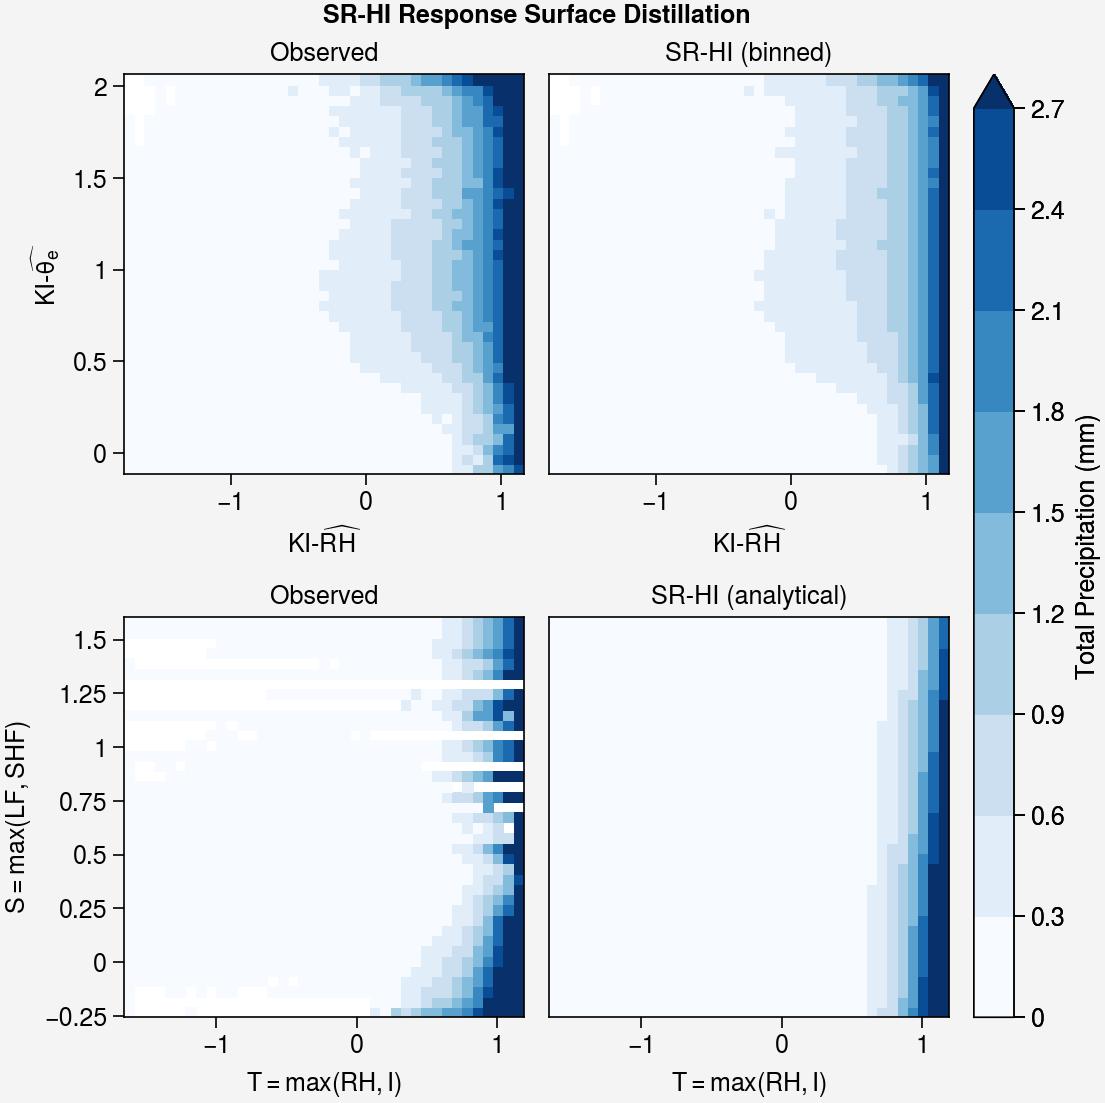

In [6]:
if 'sr_hi' not in SR_REGISTRY:
    print('sr_hi not in registry — skipping response surface analysis')
else:
    entry = SR_REGISTRY.get('sr_hi',{})
    form  = entry.get('form',OPTIMIZEDEQS['sr_hi']['form'])
    c     = entry.get('constants',OPTIMIZEDEQS['sr_hi']['init'])

    rv,tv,tsv = rhk[valid],thetaek[valid],thetaestark[valid]
    lfv,shfv  = lfnorm[valid],shfnorm[valid]
    obs       = obsflat[valid]

    tes_med = np.nanmedian(tsv)
    S_med   = np.nanmedian(np.fmax(lfv,shfv))

    rh_edges = np.linspace(*np.nanpercentile(rv,[2,98]),40)
    te_edges = np.linspace(*np.nanpercentile(tv,[2,98]),40)
    Rg,Tg    = np.meshgrid(0.5*(rh_edges[:-1]+rh_edges[1:]),
                           0.5*(te_edges[:-1]+te_edges[1:]),indexing='ij')
    Ia       = Tg + c['b']*tes_med + c['c']
    Psurf_rt = to_phys((c['a']*np.maximum(Rg,Ia) + c['d']*S_med)**3)

    T        = np.fmax(rv,tv + c['b']*tsv + c['c'])
    S        = np.fmax(lfv,shfv)
    t_edges  = np.linspace(*np.nanpercentile(T,[2,98]),40)
    s_edges  = np.linspace(*np.nanpercentile(S,[2,98]),40)
    TGr,SGr  = np.meshgrid(0.5*(t_edges[:-1]+t_edges[1:]),
                           0.5*(s_edges[:-1]+s_edges[1:]),indexing='ij')
    Psurf_ts = to_phys((c['a']*TGr + c['d']*SGr)**3)

    xc_rt,yc_rt,obsbin_rt,_ = bin_2d(rv,tv,obs,nbins=39,minsamples=20,plo=2,phi=98)
    xc_ts,yc_ts,obsbin_ts,_ = bin_2d(T,S,obs,nbins=39,minsamples=20,plo=2,phi=98)

    srhipred = MODELPRED['sr_hi'][valid]
    _,_,srbin_rt,_ = bin_2d(rv,tv,srhipred,nbins=39,minsamples=20,plo=2,phi=98)
    _,_,srbin_ts,_ = bin_2d(T,S,srhipred,nbins=39,minsamples=20,plo=2,phi=98)

    has_nn = 'nn_gauss' in MODELPRED
    if has_nn:
        nnpred = MODELPRED['nn_gauss'][valid]
        _,_,nnbin_rt,_ = bin_2d(rv,tv,nnpred,nbins=39,minsamples=20,plo=2,phi=98)

    ncols = 3 if has_nn else 2
    collabels_rt = ['Observed','SR-HI (binned)']
    collabels_ts = ['Observed','SR-HI (analytical)']
    if has_nn:
        collabels_rt.append('NN-GAUSS')

    fig,axs = pplt.subplots(nrows=2,ncols=ncols,refwidth=2,share=False)
    axsf    = np.atleast_1d(axs).ravel()

    panels_rt = [obsbin_rt,srbin_rt]
    if has_nn: panels_rt.append(nnbin_rt)
    for i,zb in enumerate(panels_rt):
        ax = axsf[i]
        m  = ax.pcolormesh(xc_rt,yc_rt,zb.T,cmap='Blues',vmin=0,vmax=3,extend='max')
        ax.format(grid=False,xlabel=r'KI-$\widehat{\mathrm{RH}}$',
                  ylabel=r'KI-$\widehat{\theta_e}$' if i==0 else '',
                  title=collabels_rt[i])
        if i>0: ax.tick_params(axis='y',left=False,labelleft=False)

    ax = axsf[ncols]
    ax.pcolormesh(xc_ts,yc_ts,obsbin_ts.T,cmap='Blues',vmin=0,vmax=3,extend='max')
    ax.format(grid=False,xlabel=r'$T = \max(\mathrm{RH}, I)$',ylabel=r'$S = \max(\mathrm{LF}, \mathrm{SHF})$',
              title='Observed')

    ax = axsf[ncols+1]
    xc_t = 0.5*(t_edges[:-1]+t_edges[1:]); xc_s = 0.5*(s_edges[:-1]+s_edges[1:])
    ax.pcolormesh(xc_t,xc_s,Psurf_ts.T,cmap='Blues',vmin=0,vmax=3,extend='max')
    ax.format(grid=False,xlabel=r'$T = \max(\mathrm{RH}, I)$',ylabel='',
              title='SR-HI (analytical)')
    ax.tick_params(axis='y',left=False,labelleft=False)

    if has_nn:
        axsf[ncols+2].set_visible(False)
    fig.colorbar(m,loc='r',label='Total Precipitation (mm)')
    fig.format(suptitle='SR-HI Response Surface Distillation')
    pplt.show()
    fig.save('../figs/fig_skillgap_1.jpg')

In [7]:
if 'sr_hi' not in MODELPRED:
    print('sr_hi not loaded — skipping regime analysis')
else:
    entry = SR_REGISTRY.get('sr_hi',{})
    c     = entry.get('constants',OPTIMIZEDEQS['sr_hi']['init'])

    rv,tv,tsv = rhk[valid],thetaek[valid],thetaestark[valid]
    lfv,shfv  = lfnorm[valid],shfnorm[valid]
    obs       = obsflat[valid]
    srhipred  = MODELPRED['sr_hi'][valid]
    resid     = obs - srhipred

    M = rv
    I = tv + c['b']*tsv + c['c']
    moisture_dom = M >= I

    featarrs = {
        r'KI-$\widehat{\mathrm{RH}}$':rv,
        r'KI-$\widehat{\theta_e}$':tv,
        r'KI-$\widehat{\theta_e^*}$':tsv,
        'LF':lfv, 'SHF':shfv, 'LHF':lhfnorm[valid]}
    if sefraw is not None: featarrs['SEF'] = sefraw[valid]
    if sdoraw is not None: featarrs['SDO'] = sdoraw[valid]

    rows = []
    for fn,fa in featarrs.items():
        for regime,mask,label in [(moisture_dom,'Moisture'),(~moisture_dom,'Instability')]:
            x,y = fa[mask],resid[mask]
            m   = np.isfinite(x)&np.isfinite(y)
            if m.sum()>10:
                rows.append({'Feature':fn,'Regime':label,'r':np.corrcoef(x[m],y[m])[0,1],
                             'N':int(m.sum())})

    fnames  = list(dict.fromkeys(r['Feature'] for r in rows))
    r_moist = {r['Feature']:r['r'] for r in rows if r['Regime']=='Moisture'}
    r_inst  = {r['Feature']:r['r'] for r in rows if r['Regime']=='Instability'}

    x     = np.arange(len(fnames))
    width = 0.35
    fig,ax = pplt.subplots(refwidth=5,refheight=2.5)
    ax.bar(x-width/2,[r_moist.get(f,0) for f in fnames],width=width,color='#1B2C61',label='Moisture-dominated')
    ax.bar(x+width/2,[r_inst.get(f,0)  for f in fnames],width=width,color='#D42028',label='Instability-dominated')
    ax.axhline(0,color='gray',linewidth=0.7)
    ax.format(xticks=x,xticklabels=fnames,xrotation=25,grid=False,
              ylabel='Pearson r  (feature vs. obs − SR-HI)',
              title=f'Regime-Conditional Feature–Residual Correlations  (moisture {moisture_dom.sum()/len(moisture_dom)*100:.0f}%)')
    ax.legend(loc='ur',ncols=1,frame=False)
    pplt.show()
    fig.save('../figs/fig_skillgap_2a.jpg')

    print(f'\nMoisture-dominated: {moisture_dom.sum():,} ({moisture_dom.mean()*100:.1f}%)')
    print(f'Instability-dominated: {(~moisture_dom).sum():,} ({(~moisture_dom).mean()*100:.1f}%)')

ValueError: not enough values to unpack (expected 3, got 2)

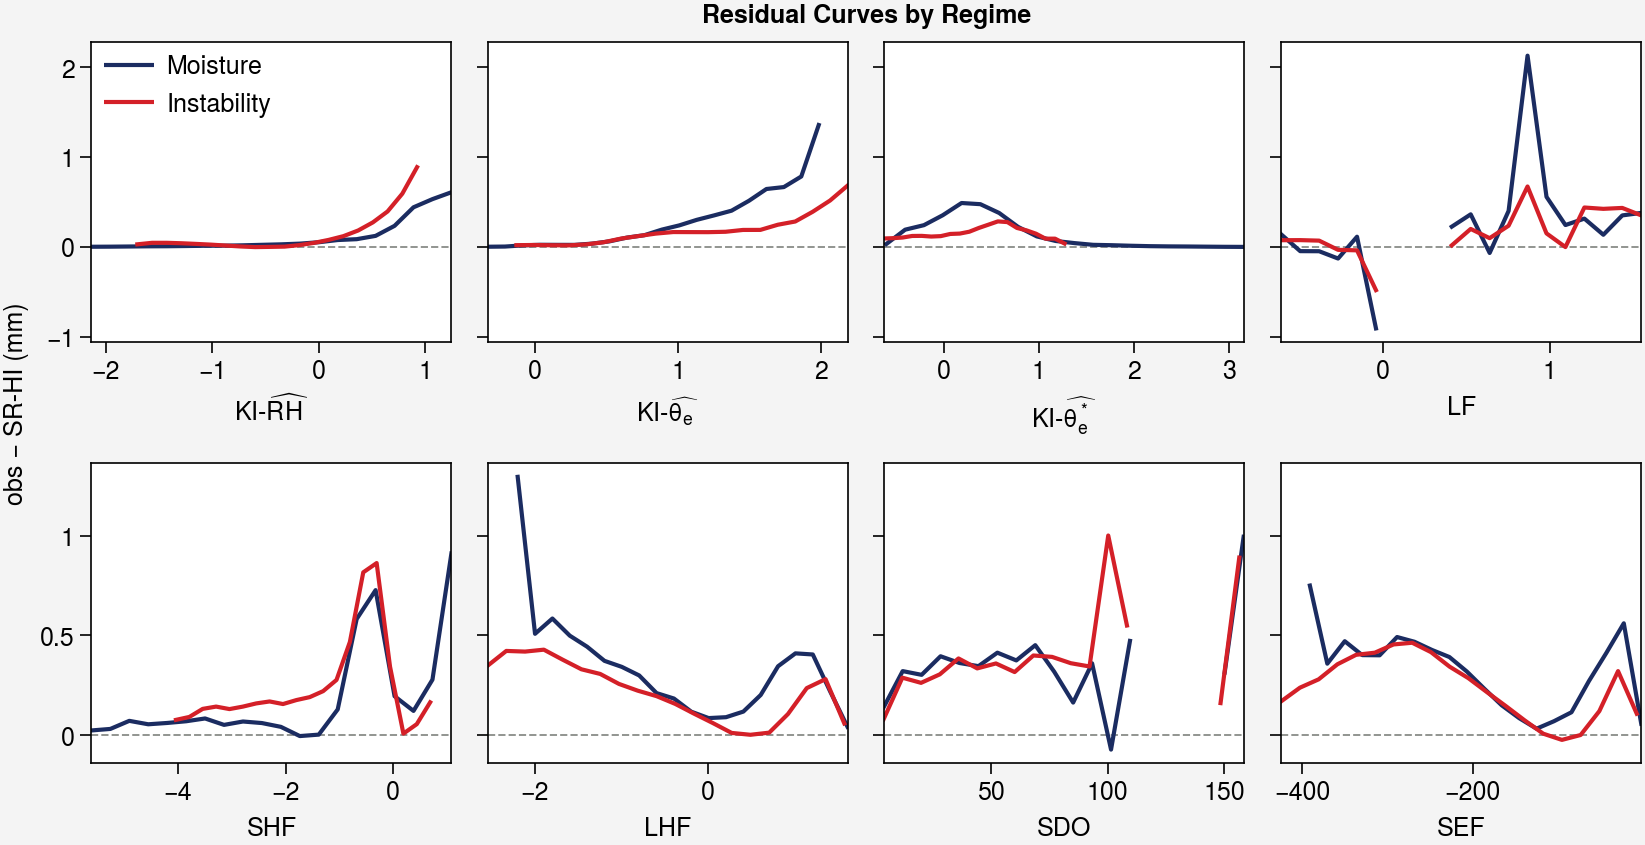

In [9]:
if 'sr_hi' not in MODELPRED:
    print('sr_hi not loaded — skipping regime residual curves')
else:
    entry = SR_REGISTRY.get('sr_hi',{})
    c     = entry.get('constants',OPTIMIZEDEQS['sr_hi']['init'])

    rv,tv,tsv = rhk[valid],thetaek[valid],thetaestark[valid]
    lfv,shfv  = lfnorm[valid],shfnorm[valid]
    obs       = obsflat[valid]
    srhipred  = MODELPRED['sr_hi'][valid]
    resid     = obs - srhipred

    M = rv
    I = tv + c['b']*tsv + c['c']
    moisture_dom = M >= I

    plotfeats = [
        ('rh', rv,  r'KI-$\widehat{\mathrm{RH}}$'),
        ('te', tv,  r'KI-$\widehat{\theta_e}$'),
        ('ts', tsv, r'KI-$\widehat{\theta_e^*}$'),
        ('lf', lfv, 'LF'),
        ('shf',shfv,'SHF'),
        ('lhf',lhfnorm[valid],'LHF')]
    if sdoraw is not None:
        plotfeats.append(('sdo',sdoraw[valid],'SDO'))
    if sefraw is not None:
        plotfeats.append(('sef',sefraw[valid],'SEF'))

    ncols = min(4,len(plotfeats)); nrows = -(-len(plotfeats)//ncols)
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=1.8,refheight=1.5,
                             sharex=False,sharey=True)
    axsf = np.atleast_1d(axs).ravel()
    for i,(ax,(_,farr,flabel)) in enumerate(zip(axsf,plotfeats)):
        ax.axhline(0,color='gray',linewidth=0.7,linestyle='--')
        for mask,color,label in [(moisture_dom,'#1B2C61','Moisture'),
                                  (~moisture_dom,'#D42028','Instability')]:
            xc,means,_ = bin_1d(farr[mask],resid[mask])
            ax.plot(xc,means,color=color,linewidth=1.5,label=label)
        ax.format(grid=False,xlabel=flabel,ylabel='obs − SR-HI (mm)' if i%ncols==0 else '')
    for ax in axsf[len(plotfeats):]: ax.set_visible(False)
    axsf[0].legend(loc='ul',ncols=1,frame=False)
    fig.format(suptitle='Residual Curves by Regime')
    pplt.show()
    fig.save('../figs/fig_skillgap_2b.jpg')

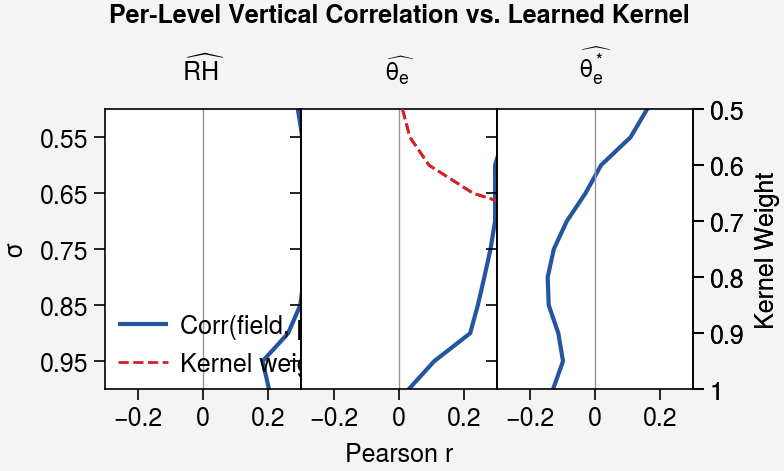

In [10]:
VARLABELS = {
    'rh':r'$\widehat{\mathrm{RH}}$',
    'thetae':r'$\widehat{\theta_e}$',
    'thetaestar':r'$\widehat{\theta_e^*}$'}

obs = obsflat[valid]

fig,axs = pplt.subplots(ncols=len(FIELDVARS),figwidth=4,refheight=1.4,share=True,space=0)
axs.format(grid=False,collabels=[VARLABELS[v] for v in FIELDVARS],
           ylabel=r'$\sigma$',ylim=(1,0.5),yticks=[0.95,0.85,0.75,0.65,0.55])

for col,varkey in enumerate(FIELDVARS):
    ax = axs[col]
    if col!=0: ax.tick_params(axis='y',left=False,labelleft=False)

    corrs = np.zeros(nsig)
    for s in range(nsig):
        x = fields[valid,col,s]
        m = np.isfinite(x)&np.isfinite(obs)
        if m.sum()>100:
            corrs[s] = np.corrcoef(x[m],obs[m])[0,1]

    ax.plot(corrs,sig,color='#2355a1',linewidth=1.5,label='Corr(field,precip)')
    ax.axvline(0,color='gray',linewidth=0.5)

    if kmean is not None:
        dax = ax.twinx()
        dax.plot(kmean[col],sig,color='#D42028',linewidth=1,linestyle='--',label='Kernel weight')
        dax.format(ylim=(1,0.5))
        if col==len(FIELDVARS)-1:
            dax.format(ylabel='Kernel Weight')
        else:
            dax.tick_params(axis='y',right=False,labelright=False)
    ax.format(xlabel='Pearson r',xlim=(-0.3,0.3),xticks=0.2)

handles  = [Line2D([],[],color='#2355a1',linewidth=1.5,label='Corr(field, precip)')]
if kmean is not None:
    handles.append(Line2D([],[],color='#D42028',linewidth=1,linestyle='--',label='Kernel weight'))
axs[0].legend(handles,loc='ll',ncols=1,frame=False)
fig.format(suptitle='Per-Level Vertical Correlation vs. Learned Kernel')
pplt.show()
fig.save('../figs/fig_skillgap_3.jpg')

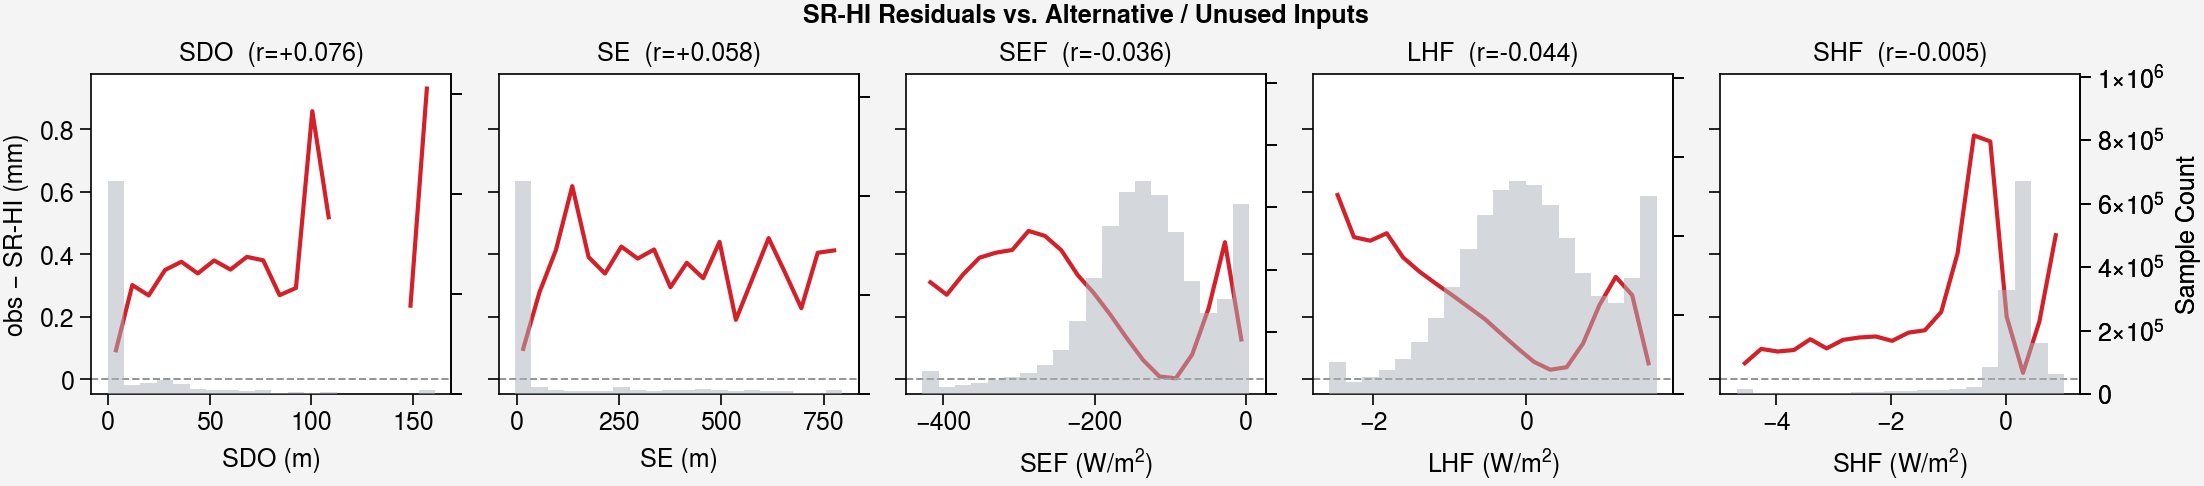


sr_gauss_v2 predictions not found — run pending


In [14]:
if 'sr_hi' not in MODELPRED:
    print('sr_hi not loaded — skipping alternative-inputs analysis')
else:
    obs      = obsflat[valid]
    srhipred = MODELPRED['sr_hi'][valid]
    resid    = obs - srhipred

    altfeats = []
    if sdoraw is not None: altfeats.append(('SDO','m',sdoraw[valid]))
    if seraw  is not None: altfeats.append(('SE','m',seraw[valid]))
    if sefraw is not None: altfeats.append(('SEF',r'W/m$^2$',sefraw[valid]))
    altfeats.append(('LHF',r'W/m$^2$',lhfnorm[valid]))
    altfeats.append(('SHF',r'W/m$^2$',shfnorm[valid]))

    ncols = min(len(altfeats),5); nrows = -(-len(altfeats)//ncols)
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=1.8,refheight=1.6,
                             sharex=False,sharey=True)
    axsf = np.atleast_1d(axs).ravel()
    for i,(ax,(fname,funit,farr)) in enumerate(zip(axsf,altfeats)):
        m = np.isfinite(farr)&np.isfinite(resid)
        rval = np.corrcoef(farr[m],resid[m])[0,1] if m.sum()>10 else np.nan
        xc,means,counts = bin_1d(farr,resid)
        dax = ax.twinx()
        dax.bar(xc,counts,width=xc[1]-xc[0],absolute_width=True,edgecolor='none',
                color='gray5',alpha=0.3)
        dax.format(ylim=(0,1.5*counts.max()),yformatter='sci')
        if i==len(altfeats)-1:
            dax.format(ylabel='Sample Count')
        else:
            dax.tick_params(axis='y',labelright=False)
        ax.plot(xc,means,color='#D42028',linewidth=1.5)
        ax.axhline(0,color='gray',linewidth=0.7,linestyle='--')
        ax.format(grid=False,xlabel=f'{fname} ({funit})',
                  ylabel='obs − SR-HI (mm)' if i%ncols==0 else '',
                  title=f'{fname}  (r={rval:+.3f})')
    for ax in axsf[len(altfeats):]: ax.set_visible(False)
    fig.format(suptitle='SR-HI Residuals vs. Alternative / Unused Inputs')
    pplt.show()
    fig.save('../figs/fig_skillgap_4a.jpg')

    v2pred = load_pred('sr_gauss_v2')
    if v2pred is not None:
        v2r2 = r2(obs,v2pred[valid])
        hir2 = r2(obs,srhipred)
        print(f'\nsr_gauss_v2 R² = {v2r2:.3f}  vs  sr_hi R² = {hir2:.3f}')

        fig,axs = pplt.subplots(nrows=1,ncols=2,refwidth=2.5,refheight=2,share=False)
        for ax,name,pred,color in [(axs[0],'SR-HI',srhipred,COLORS.get('sr_hi','#2355a1')),
                                    (axs[1],'SR-GAUSS-V2',v2pred[valid],'#539ed4')]:
            xc,biasbin,_ = bin_1d(obs,pred-obs,nbins=25,minsamples=100,plo=0,phi=99)
            ax.plot(xc,biasbin,color=color,linewidth=1.5)
            ax.axhline(0,color='gray',linewidth=0.7,linestyle='--')
            ax.format(grid=False,xlabel='Observed Precipitation (mm)',
                      ylabel='Predicted − Observed (mm)',
                      title=f'{name}  (R²={r2(obs,pred):.3f})')
        pplt.show()
        fig.save('../figs/fig_skillgap_4b.jpg')
    else:
        print('\nsr_gauss_v2 predictions not found — run pending')

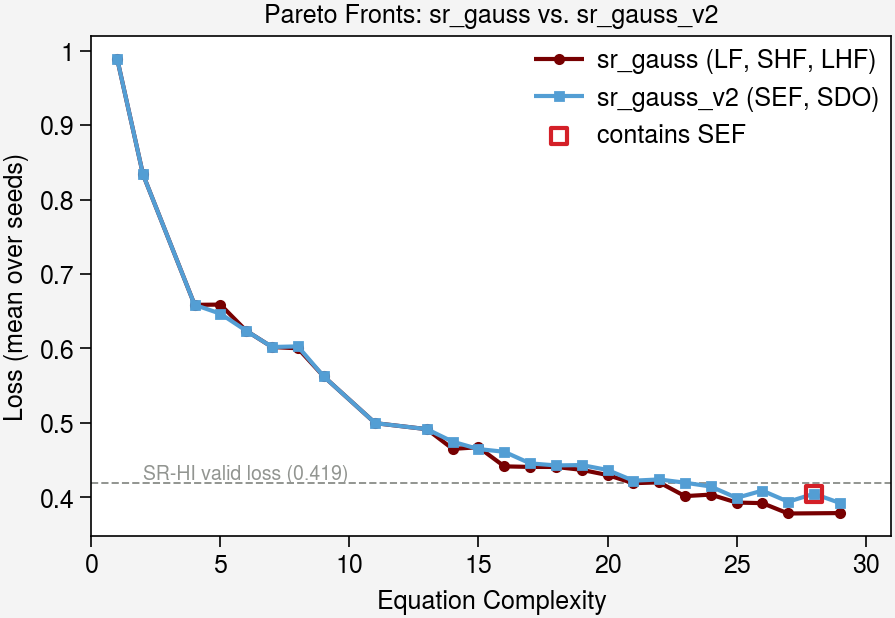


sr_gauss_v2 equations where SEF/SDO appear:
  C=28  loss=0.4049  cube(max(rh, ((-0.2827512 - thetaestar) * 1.3810202) + thetae) + (max(sef, lf + -0.74187785) * -0.0898269)) * 1.8627418


In [12]:
SRDIR   = os.path.join(MODELSDIR,'sr')
SRSEEDS = MODELS['sr']['seeds']

def load_pareto(run,seeds=SRSEEDS):
    frames = []
    for seed in seeds:
        path = os.path.join(SRDIR,f'{run}_{seed}_equations.csv')
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['seed'] = seed
            frames.append(df)
    if not frames: return None
    df = pd.concat(frames,ignore_index=True)
    return df.groupby('complexity').agg(loss=('loss','mean'),equation=('equation','first')).reset_index()

pareto_gauss = load_pareto('sr_gauss')
pareto_v2    = load_pareto('sr_gauss_v2')

if pareto_gauss is not None and pareto_v2 is not None:
    v2_has_sef = []
    v2_has_sdo = []
    for _,row in pareto_v2.iterrows():
        eq = str(row['equation'])
        v2_has_sef.append('sef' in eq)
        v2_has_sdo.append('sdo' in eq)

    fig,ax = pplt.subplots(refwidth=4,refheight=2.5)
    ax.plot(pareto_gauss['complexity'],pareto_gauss['loss'],color=COLORS.get('sr_hi','#2355a1'),
            linewidth=1.5,marker='o',markersize=3,label='sr_gauss (LF, SHF, LHF)',zorder=3)
    ax.plot(pareto_v2['complexity'],pareto_v2['loss'],color='#539ed4',
            linewidth=1.5,marker='s',markersize=3,label='sr_gauss_v2 (SEF, SDO)',zorder=3)

    sef_mask = np.array(v2_has_sef)
    sdo_mask = np.array(v2_has_sdo)
    if sef_mask.any():
        ax.scatter(pareto_v2.loc[sef_mask,'complexity'],pareto_v2.loc[sef_mask,'loss'],
                   marker='s',s=30,facecolors='none',edgecolors='#D42028',linewidths=1.5,
                   label='contains SEF',zorder=4)
    if sdo_mask.any():
        ax.scatter(pareto_v2.loc[sdo_mask,'complexity'],pareto_v2.loc[sdo_mask,'loss'],
                   marker='D',s=25,facecolors='none',edgecolors='#F2C85E',linewidths=1.5,
                   label='contains SDO',zorder=4)

    sr_hi_loss = OPTIMIZEDEQS['sr_hi'].get('refcomplexity',23)
    opt = pd.read_csv(os.path.join(SRDIR,'optimized_equations.csv'))
    hiloss = opt.loc[opt['name']=='sr_hi','valid_loss'].values
    if len(hiloss):
        ax.axhline(hiloss[0],color='gray',linewidth=0.7,linestyle='--',zorder=1)
        ax.text(2,hiloss[0]+0.005,f'SR-HI valid loss ({hiloss[0]:.3f})',fontsize=7,color='gray')

    ax.format(grid=False,xlabel='Equation Complexity',ylabel='Loss (mean over seeds)',
              title='Pareto Fronts: sr_gauss vs. sr_gauss_v2',xlim=(0,31))
    ax.legend(loc='ur',ncols=1,frame=False)
    pplt.show()
    fig.save('../figs/fig_skillgap_4c.jpg')

    print('\nsr_gauss_v2 equations where SEF/SDO appear:')
    for _,row in pareto_v2.iterrows():
        eq = str(row['equation'])
        if 'sef' in eq or 'sdo' in eq:
            print(f'  C={int(row["complexity"]):2d}  loss={row["loss"]:.4f}  {eq}')
else:
    print('Pareto CSVs not found for one or both runs')

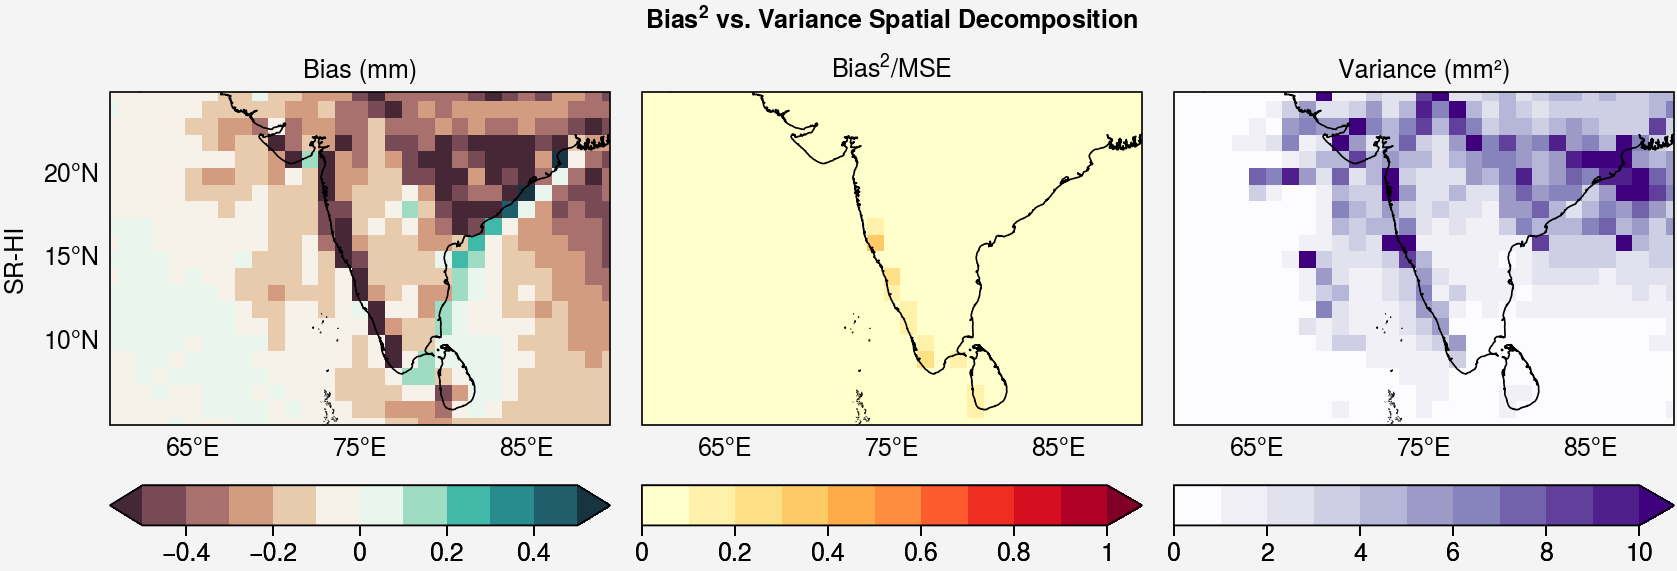

All       bias=-0.167 mm   MSE=2.775   bias²/MSE=1.00%
Land      bias=-0.365 mm   MSE=5.188   bias²/MSE=2.57%
Ocean     bias=-0.087 mm   MSE=1.747   bias²/MSE=0.43%


In [15]:
if 'sr_hi' not in MODELPRED:
    print('sr_hi not loaded — skipping bias²/variance decomposition')
else:
    obs3d  = obsflat.reshape(ntime,nlat,nlon)
    srhi3d = MODELPRED['sr_hi'].reshape(ntime,nlat,nlon)

    bias_map     = np.nanmean(srhi3d - obs3d,axis=0)
    mse_map      = np.nanmean((srhi3d - obs3d)**2,axis=0)
    variance_map = mse_map - bias_map**2
    bias2frac    = np.where(mse_map>0,bias_map**2/mse_map,np.nan)

    panels = [('Bias (mm)',bias_map,'DryWet',-0.5,0.5),
              (r'Bias$^2$/MSE',bias2frac,'YlOrRd',0,1),
              ('Variance (mm²)',variance_map,'Purples',0,None)]
    if variance_map[np.isfinite(variance_map)].size>0:
        panels[2] = ('Variance (mm²)',variance_map,'Purples',0,
                     float(np.nanpercentile(variance_map,98)))

    kwmap = dict(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
                 latlines=[10,15,20],lonlines=[65,75,85],grid=False)

    has_nn = 'nn_gauss' in MODELPRED
    nrows  = 2 if has_nn else 1

    if has_nn:
        nn3d          = MODELPRED['nn_gauss'].reshape(ntime,nlat,nlon)
        nn_bias_map   = np.nanmean(nn3d - obs3d,axis=0)
        nn_mse_map    = np.nanmean((nn3d - obs3d)**2,axis=0)
        nn_var_map    = nn_mse_map - nn_bias_map**2
        nn_bias2frac  = np.where(nn_mse_map>0,nn_bias_map**2/nn_mse_map,np.nan)
        nn_panels     = [('NN-GAUSS Bias (mm)',nn_bias_map,'DryWet',-0.5,0.5),
                         (r'NN-GAUSS Bias$^2$/MSE',nn_bias2frac,'YlOrRd',0,1),
                         ('NN-GAUSS Variance (mm²)',nn_var_map,'Purples',0,panels[2][4])]

    fig,axs = pplt.subplots(nrows=nrows,ncols=3,proj='cyl',refwidth=2.5,share=False)
    axsf    = np.atleast_1d(axs).ravel()

    for i,(title,arr,cmap,vmin,vmax) in enumerate(panels):
        ax = axsf[i]
        extend = 'both' if cmap=='DryWet' else 'max'
        m  = ax.pcolormesh(lon,lat,arr,cmap=cmap,vmin=vmin,vmax=vmax,extend=extend)
        ax.format(title=title,latlabels='l' if i==0 else False,lonlabels='b',**kwmap)
        fig.colorbar(m,loc='b',col=i+1)

    if has_nn:
        for i,(title,arr,cmap,vmin,vmax) in enumerate(nn_panels):
            ax = axsf[3+i]
            extend = 'both' if cmap=='DryWet' else 'max'
            m  = ax.pcolormesh(lon,lat,arr,cmap=cmap,vmin=vmin,vmax=vmax,extend=extend)
            ax.format(title=title,latlabels='l' if i==0 else False,lonlabels='b',**kwmap)

    rowlabels = ['SR-HI']
    if has_nn: rowlabels.append('NN-GAUSS')
    fig.format(suptitle=r'Bias$^2$ vs. Variance Spatial Decomposition',rowlabels=rowlabels)
    pplt.show()
    land   = lfraw > 0.9
    ocean  = lfraw < 0.1
    validm = valid & np.isfinite(MODELPRED['sr_hi'])
    for region,mask in [('All',valid),('Land',valid&land),('Ocean',valid&ocean)]:
        o = obsflat[mask]; p = MODELPRED['sr_hi'][mask]
        bias  = np.nanmean(p-o)
        mse   = np.nanmean((p-o)**2)
        b2f   = bias**2/mse if mse>0 else np.nan
        print(f'{region:8s}  bias={bias:+.3f} mm   MSE={mse:.3f}   bias²/MSE={b2f:.2%}')